In [514]:
import numpy as np

In [515]:
from softisoics import profiles, sampling, utils
from softisoics.constants import G
from softisoics.ICs_writer import ICsWriter

In [516]:
import importlib

importlib.reload(profiles)
importlib.reload(sampling)
importlib.reload(utils)

<module 'softisoics.utils' from '/Users/vinhtran/Data/Research/Mark/SoftIsoICs/SoftIsoICs/src/softisoics/utils.py'>

In [517]:
import warnings

from scipy.integrate import IntegrationWarning

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter("ignore", category=IntegrationWarning)

In [518]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [519]:
class NFWProfile(profiles.BaseSingleComponentProfile):
    def __init__(self, c=10, **kwargs):
        self.c = c
        super().__init__(**kwargs, halo_edge=c)

    def _nfw_density(self, r):
        return 1 / r / (1 + r) ** 2

    def _decay_density(self, r):
        eps = 1 - (1 + 3 * self.c) / (1 + self.c)
        return (
            1
            / (self.c * (1 + self.c) ** 2)
            * (r / self.c) ** eps
            * np.exp(-(r / self.c - 1))
        )

    def _get_rho_bins(self, r_bins):
        return np.where(
            r_bins < self.c, self._nfw_density(r_bins), self._decay_density(r_bins)
        )

In [520]:
nfw_profile = NFWProfile(
    c=8.28,
    r_bin_min=1e-5,
    r_bin_max=1e3,
    N_bins=10000,
    # epsilon=0.1,
)

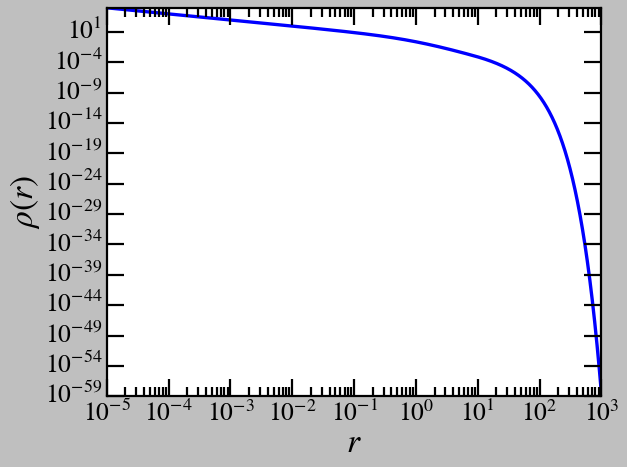

In [521]:
plt.plot(nfw_profile.r_bins, nfw_profile.rho_bins)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho (r)$")

plt.tight_layout()
plt.show()

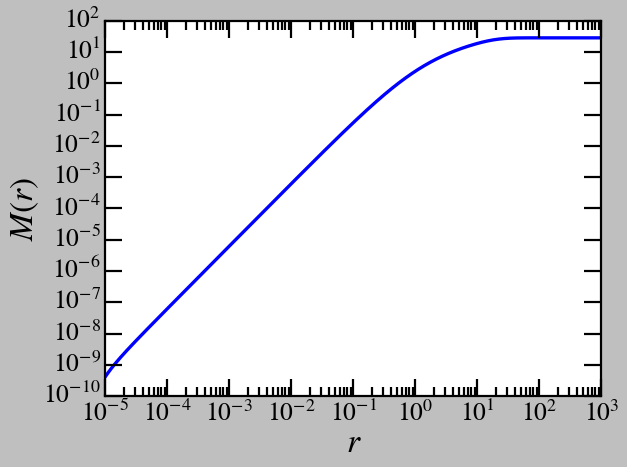

In [522]:
plt.plot(nfw_profile.r_bins, nfw_profile.mass_bins)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$M (r)$")

plt.tight_layout()
plt.show()

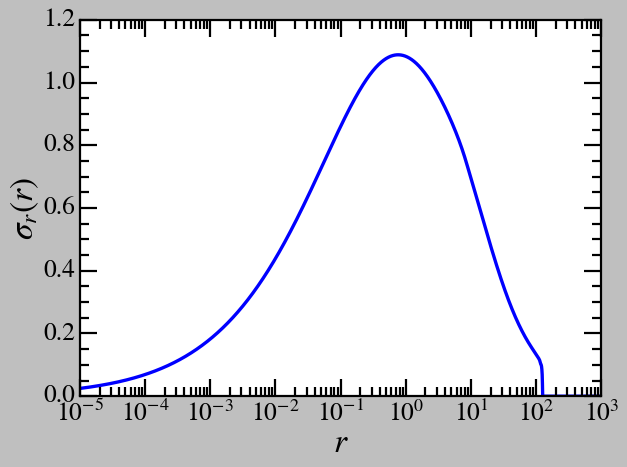

In [523]:
plt.plot(nfw_profile.r_bins, nfw_profile.sigma_r_bins)

plt.xscale("log")
# plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r (r)$")

plt.tight_layout()
plt.show()

In [524]:
eddington = profiles.BaseEddingtonDistribution(DM_profile=nfw_profile, gas_profile=None)

Eddington's inversion: 100%|██████████| 9999/9999 [00:23<00:00, 431.14it/s] 


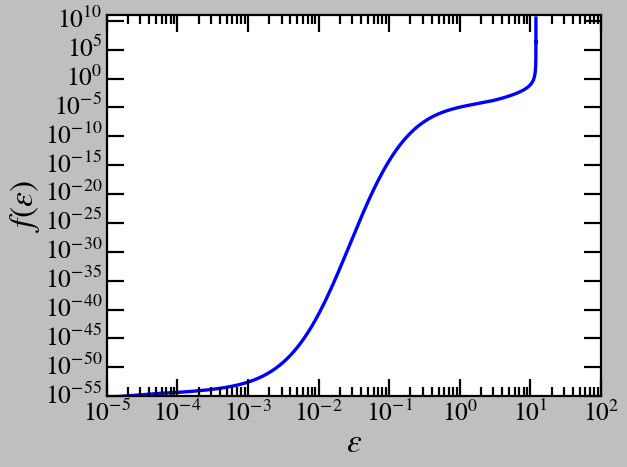

In [525]:
plt.plot(eddington.eps_bins, eddington.DM_f_eps_bins)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$f(\epsilon)$")

plt.tight_layout()
plt.show()

In [526]:
reconstructed_rho_bins = eddington.reconstruct_density(
    total_phi_bins=eddington.total_phi_bins,
    eps_bins=eddington.eps_bins,
    f_eps_bins=eddington.DM_f_eps_bins,
)

Reconstructing densities: 100%|██████████| 10000/10000 [00:15<00:00, 646.22it/s]


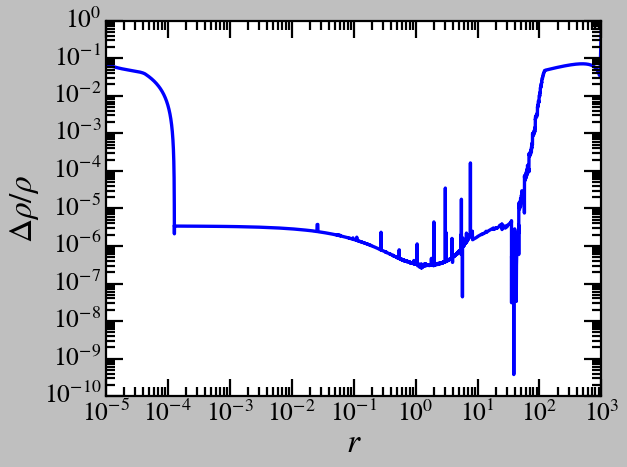

In [527]:
plt.plot(nfw_profile.r_bins, np.abs(1 - reconstructed_rho_bins / nfw_profile.rho_bins))

plt.xlabel(r"$r$")
plt.ylabel(r"$\Delta \rho / \rho$")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

In [528]:
N_200 = 1e6

N_part = utils.get_N_part_from_N_200(
    N_200=N_200,
    r200=nfw_profile.c,
    r_sample_max=5 * nfw_profile.c,
    r_bins=nfw_profile.r_bins,
    mass_bins=nfw_profile.mass_bins,
)

In [529]:
sampler = sampling.SampleParticles(
    r_bins=nfw_profile.r_bins,
    rho_bins=nfw_profile.rho_bins,
    mass_bins=nfw_profile.mass_bins,
    total_phi_bins=eddington.total_phi_bins,
    eps_bins=eddington.eps_bins,
    f_eps_bins=eddington.DM_f_eps_bins,
    r_sample_min=1e-4,
    r_sample_max=5 * nfw_profile.c,
    N_part=N_part,
    kappa_L=0.5,
)

Sampling velocities: 100%|██████████| 9999/9999 [00:12<00:00, 771.79it/s] 


In [530]:
part_coords = np.vstack([sampler.part_x, sampler.part_y, sampler.part_z]).T

part_velocs = np.vstack([sampler.part_vx, sampler.part_vy, sampler.part_vz]).T

part_mass = sampler.part_mass

In [ ]:
halo = utils.Halo()
halo.input_from_particles(
    part_coords=part_coords, part_velocs=part_velocs, part_mass=part_mass
)

sampled_L_x, sampled_L_y, sampled_L_z = halo.get_angular_momenta()

sigma_L = np.sqrt(part_mass) * nfw_profile.sigma_L_scaler

print(f"L_max / sigma_L: {(nfw_profile.L_max / sigma_L):.2e}")  # noqa: T201
print(f"L_x / sigma_L: {(sampled_L_x / sigma_L):.2e}")  # noqa: T201
print(f"L_y / sigma_L: {(sampled_L_y / sigma_L):.2e}")  # noqa: T201
print(f"L_z / sigma_L: {(sampled_L_z / sigma_L):.2e}")  # noqa: T201

(
    sampled_r_bins,
    sampled_rho_bins,
    sampled_rho_bins_err,
    sampled_sigma_r_bins,
    sampled_sigma_r_bins_err,
) = halo.get_profiles()

L_max / sigma_L: 8.570e+02
L_x / sigma_L: -1.258e+00
L_y / sigma_L: -2.402e-01
L_z / sigma_L: 4.291e+02


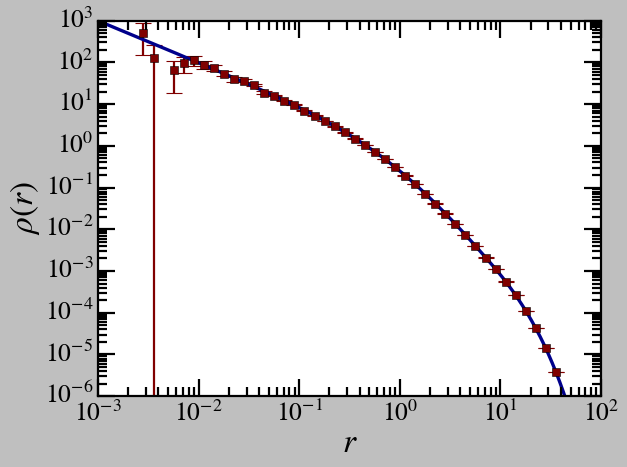

In [532]:
plt.errorbar(
    sampled_r_bins,
    sampled_rho_bins,
    yerr=sampled_rho_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(nfw_profile.r_bins, nfw_profile.rho_bins, color="darkblue")

plt.xlim(1e-3, 1e2)
plt.ylim(1e-6, 1e3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho (r)$")

plt.tight_layout()
plt.show()

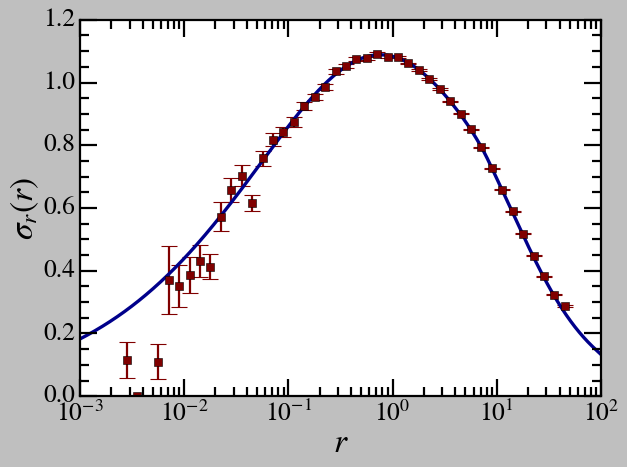

In [533]:
plt.errorbar(
    sampled_r_bins,
    sampled_sigma_r_bins,
    yerr=sampled_sigma_r_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(nfw_profile.r_bins, nfw_profile.sigma_r_bins, color="darkblue")

plt.xlim(1e-3, 1e2)

plt.xscale("log")
# plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r (r)$")

plt.tight_layout()
plt.show()

In [534]:
rs = 25.48
rhos = 3.60e06

In [535]:
part_coords = part_coords * rs
part_velocs = part_velocs * np.sqrt(G * rhos * rs**2)
part_masses = np.full(N_part, part_mass * rhos * rs**3 / 1e10)
part_ids = np.arange(1, N_part + 1)

In [536]:
writer = ICsWriter(
    part_coords=part_coords,
    part_velocs=part_velocs,
    part_masses=part_masses,
    part_ids=part_ids,
)

writer.write(filename="../../ICs/ICs_m1e12_N1e6_kappa05_control.hdf5")